# Image Reconstruction Under Corruption
**Goal:** Learn to reconstruct clean images from corrupted ones using training pairs.  
**Metric:** MSE (lower is better)  
**Images:** 32×32 RGB  
**Data:** 48,000 train pairs, 12,000 test corrupted images

##  Setup & Imports

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image
from tqdm.notebook import tqdm
import cv2
import warnings
warnings.filterwarnings('ignore')

# Deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using: {DEVICE}')

PyTorch: 2.10.0+cu128
CUDA available: True
Using: cuda


In [25]:
# ── Paths (adjust BASE if running from a different directory) ──
BASE        = '/kaggle/input/competitions/image-reconstruction-under-corruption/Datasets'
TRAIN_CLEAN = os.path.join(BASE, 'train_clean')
TRAIN_COR   = os.path.join(BASE, 'train_corrupt')
TEST_COR    = os.path.join(BASE, 'test_corrupt')
TRAIN_CSV   = os.path.join(BASE, 'train.csv')
SAMPLE_SUB  = os.path.join(BASE, 'sample_submission.csv')

IMG_SIZE    = 32
N_PIXELS    = IMG_SIZE * IMG_SIZE * 3   # 3072

train_df = pd.read_csv(TRAIN_CSV)
print(f'Train samples: {len(train_df)}')
print(train_df.head())

Train samples: 48000
            id       class   clean_filename corrupt_filename
0  train_00000         dog  train_00000.png  train_00000.png
1  train_00001  automobile  train_00001.png  train_00001.png
2  train_00002  automobile  train_00002.png  train_00002.png
3  train_00003       horse  train_00003.png  train_00003.png
4  train_00004    airplane  train_00004.png  train_00004.png


## Exploratory Data Analysis

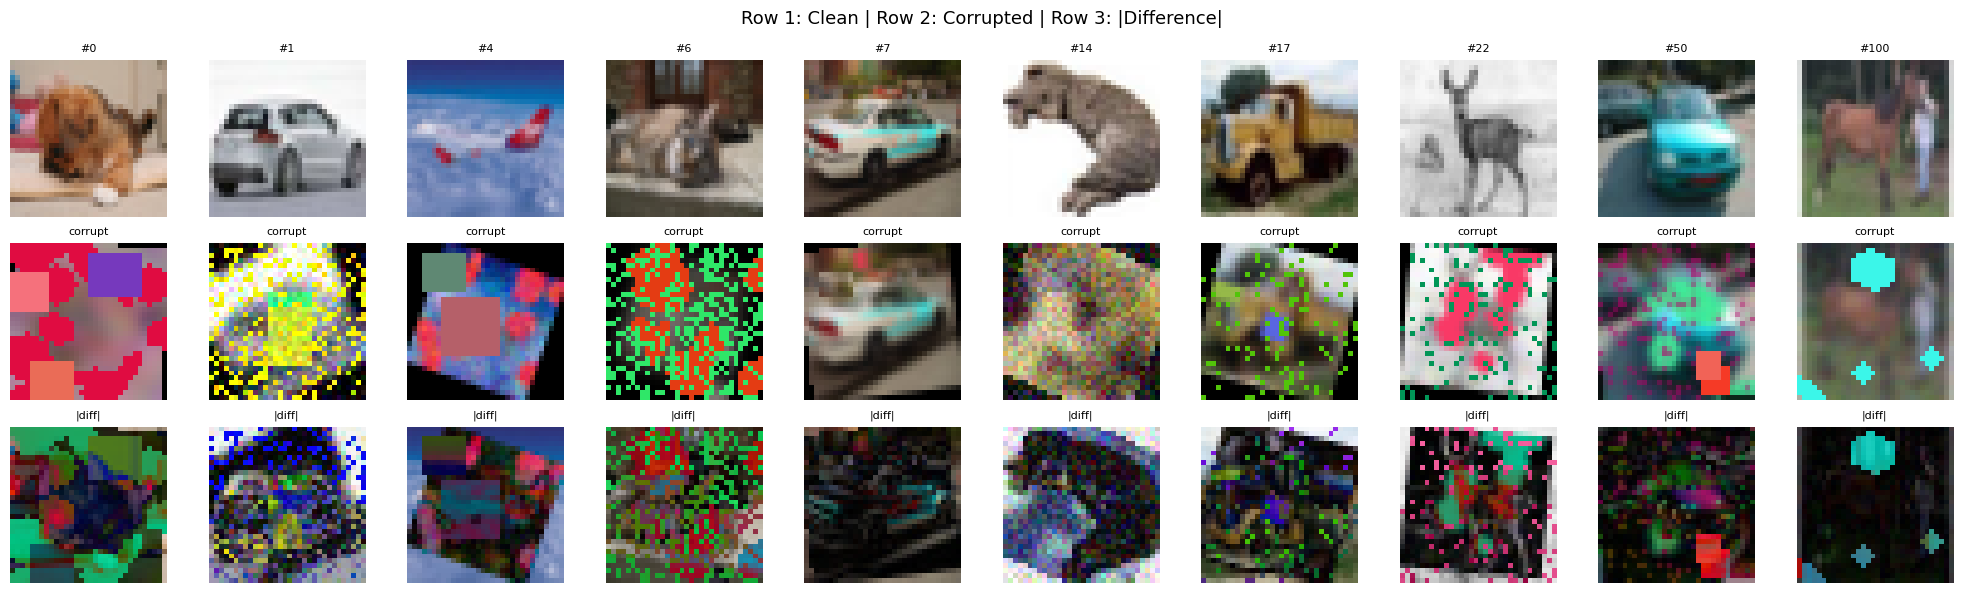

In [26]:
# ── Visualise 10 training pairs ──
picks = [0, 1, 4, 6, 7, 14, 17, 22, 50, 100]
fig, axes = plt.subplots(3, len(picks), figsize=(20, 6))
fig.suptitle('Row 1: Clean | Row 2: Corrupted | Row 3: |Difference|', fontsize=13)

for col, i in enumerate(picks):
    name = f'train_{i:05d}.png'
    clean   = np.array(Image.open(os.path.join(TRAIN_CLEAN, name)))
    corrupt = np.array(Image.open(os.path.join(TRAIN_COR,   name)))
    diff    = np.abs(clean.astype(int) - corrupt.astype(int)).clip(0, 255).astype(np.uint8)

    axes[0, col].imshow(clean);   axes[0, col].set_title(f'#{i}', fontsize=8)
    axes[1, col].imshow(corrupt); axes[1, col].set_title('corrupt', fontsize=8)
    axes[2, col].imshow(diff, cmap='hot'); axes[2, col].set_title('|diff|', fontsize=8)
    for row in range(3): axes[row, col].axis('off')

plt.tight_layout()
plt.show()

Computing MSE:   0%|          | 0/1000 [00:00<?, ?it/s]

MSE stats over 1000 images:
  Mean: 4872.0  |  Median: 4148.7
  Min:  58.2   |  Max:  21376.5


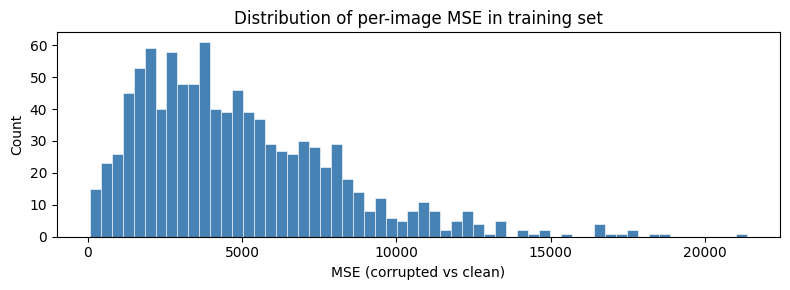

In [30]:
# ── Per-image MSE distribution across 1000 samples ──
mse_list = []
sample_files = sorted(os.listdir(TRAIN_CLEAN))[:1000]

for fname in tqdm(sample_files, desc='Computing MSE'):
    clean   = np.array(Image.open(os.path.join(TRAIN_CLEAN, fname))).astype(float)
    corrupt = np.array(Image.open(os.path.join(TRAIN_COR,   fname))).astype(float)
    mse_list.append(((clean - corrupt)**2).mean())

mse_arr = np.array(mse_list)
print(f'MSE stats over 1000 images:')
print(f'  Mean: {mse_arr.mean():.1f}  |  Median: {np.median(mse_arr):.1f}')
print(f'  Min:  {mse_arr.min():.1f}   |  Max:  {mse_arr.max():.1f}')

plt.figure(figsize=(8, 3))
plt.hist(mse_arr, bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
plt.xlabel('MSE (corrupted vs clean)')
plt.ylabel('Count')
plt.title('Distribution of per-image MSE in training set')
plt.tight_layout()
plt.show()

Profiling:   0%|          | 0/500 [00:00<?, ?it/s]

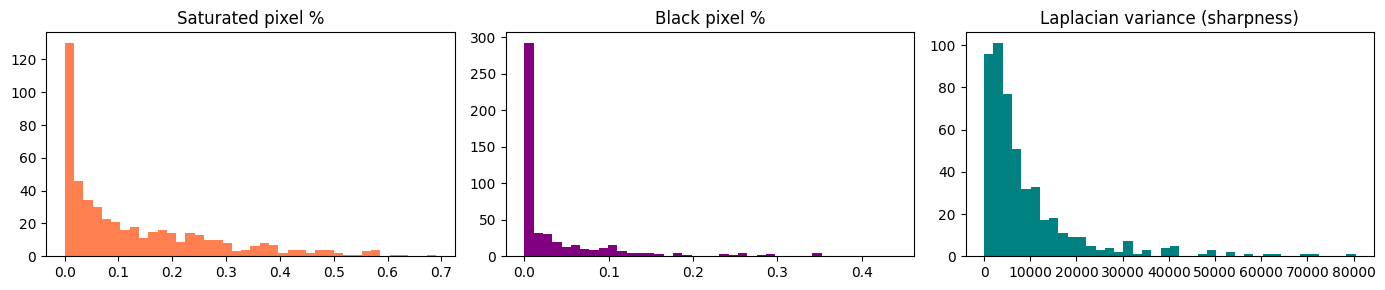

Images with >5% saturated pixels: 58.4%
Images with >5% black pixels:     24.2%
Images with low sharpness (<80):  2.2%


In [32]:
# ── Corruption type profiling ──
def profile_corruption(corrupt_u8):
    hsv = cv2.cvtColor(corrupt_u8, cv2.COLOR_RGB2HSV)
    sat_pct  = (hsv[:,:,1] > 200).mean()
    black_pct = (corrupt_u8 == 0).all(axis=2).mean()
    gray  = cv2.cvtColor(corrupt_u8, cv2.COLOR_RGB2GRAY)
    lap_var = cv2.Laplacian(gray.astype(np.float64), cv2.CV_64F).var()
    return sat_pct, black_pct, lap_var

sat_list, blk_list, lap_list = [], [], []
for fname in tqdm(sample_files[:500], desc='Profiling'):
    img = np.array(Image.open(os.path.join(TRAIN_COR, fname)))
    s, b, l = profile_corruption(img)
    sat_list.append(s); blk_list.append(b); lap_list.append(l)

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
axes[0].hist(sat_list, bins=40, color='coral');   axes[0].set_title('Saturated pixel %')
axes[1].hist(blk_list, bins=40, color='purple');  axes[1].set_title('Black pixel %')
axes[2].hist(lap_list, bins=40, color='teal');    axes[2].set_title('Laplacian variance (sharpness)')
plt.tight_layout(); plt.show()

print(f'Images with >5% saturated pixels: {(np.array(sat_list)>0.05).mean()*100:.1f}%')
print(f'Images with >5% black pixels:     {(np.array(blk_list)>0.05).mean()*100:.1f}%')
print(f'Images with low sharpness (<80):  {(np.array(lap_list)<80).mean()*100:.1f}%')

## Dataset Class

In [33]:
class ReconstructionDataset(Dataset):
    """
    Returns (corrupt_tensor, clean_tensor) pairs normalised to [-1, 1].
    Optionally applies data augmentation (random horizontal flip).
    """
    def __init__(self, filenames, clean_dir, corrupt_dir, augment=False):
        self.filenames   = filenames
        self.clean_dir   = clean_dir
        self.corrupt_dir = corrupt_dir
        self.augment     = augment

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        fname   = self.filenames[idx]
        clean   = np.array(Image.open(os.path.join(self.clean_dir,   fname))).astype(np.float32)
        corrupt = np.array(Image.open(os.path.join(self.corrupt_dir, fname))).astype(np.float32)

        # Normalise to [-1, 1]
        clean   = (clean   / 127.5) - 1.0
        corrupt = (corrupt / 127.5) - 1.0

        # HWC → CHW
        clean   = torch.from_numpy(clean.transpose(2, 0, 1))
        corrupt = torch.from_numpy(corrupt.transpose(2, 0, 1))

        # Augmentation: consistent flip on both
        if self.augment and torch.rand(1).item() > 0.5:
            clean   = torch.flip(clean,   dims=[2])
            corrupt = torch.flip(corrupt, dims=[2])

        return corrupt, clean


class TestDataset(Dataset):
    """Returns (image_id, corrupt_tensor) for test images."""
    def __init__(self, image_ids, corrupt_dir):
        self.image_ids   = image_ids
        self.corrupt_dir = corrupt_dir

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id  = self.image_ids[idx]
        fpath   = os.path.join(self.corrupt_dir, img_id + '.png')
        corrupt = np.array(Image.open(fpath)).astype(np.float32)
        corrupt = (corrupt / 127.5) - 1.0
        corrupt = torch.from_numpy(corrupt.transpose(2, 0, 1))
        return img_id, corrupt

In [34]:
# ── Train / validation split ──
all_files = sorted(os.listdir(TRAIN_CLEAN))   # 48,000 files
np.random.seed(42)
idx       = np.random.permutation(len(all_files))
val_n     = 4000    # hold out 4k for validation
val_files = [all_files[i] for i in idx[:val_n]]
trn_files = [all_files[i] for i in idx[val_n:]]

print(f'Train: {len(trn_files)} | Val: {len(val_files)}')

BATCH     = 128
trn_ds    = ReconstructionDataset(trn_files, TRAIN_CLEAN, TRAIN_COR, augment=True)
val_ds    = ReconstructionDataset(val_files, TRAIN_CLEAN, TRAIN_COR, augment=False)
trn_dl    = DataLoader(trn_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_dl    = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(trn_dl)} | Val batches: {len(val_dl)}')

Train: 44000 | Val: 4000
Train batches: 344 | Val batches: 32


## Model Architecture — DnCNN-style U-Net

In [35]:
# ── Residual block ──
class ResBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
        )
    def forward(self, x):
        return F.relu(x + self.net(x), inplace=True)


# ── Encoder block ──
class EncoderBlock(nn.Module):
    def __init__(self, in_ch, out_ch, n_res=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            *[ResBlock(out_ch) for _ in range(n_res)]
        )
        self.pool = nn.MaxPool2d(2)

    def forward(self, x):
        skip = self.conv(x)
        return self.pool(skip), skip


# ── Decoder block ──
class DecoderBlock(nn.Module):
    def __init__(self, in_ch, skip_ch, out_ch, n_res=2):
        super().__init__()
        self.up   = nn.ConvTranspose2d(in_ch, out_ch, 2, stride=2)
        self.conv = nn.Sequential(
            nn.Conv2d(out_ch + skip_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            *[ResBlock(out_ch) for _ in range(n_res)]
        )

    def forward(self, x, skip):
        x = self.up(x)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)


# ── Full U-Net ──
class ResUNet(nn.Module):
    """
    Residual U-Net for 32×32 RGB image restoration.
    Input: (B, 3, 32, 32)  Output: (B, 3, 32, 32)
    The model predicts the RESIDUAL (noise) and subtracts it from the input.
    """
    def __init__(self, base_ch=128):
        super().__init__()
        # Encoder
        self.enc1 = EncoderBlock(3,        base_ch,     n_res=2)   # 32→16
        self.enc2 = EncoderBlock(base_ch,  base_ch*2,   n_res=2)   # 16→8
        self.enc3 = EncoderBlock(base_ch*2,base_ch*4,   n_res=2)   # 8→4
        # Bottleneck
        self.bot  = nn.Sequential(
            nn.Conv2d(base_ch*4, base_ch*8, 3, padding=1, bias=False),
            nn.BatchNorm2d(base_ch*8),
            nn.ReLU(inplace=True),
            ResBlock(base_ch*8),
            ResBlock(base_ch*8),
        )
        # Decoder
        self.dec3 = DecoderBlock(base_ch*8, base_ch*4, base_ch*4, n_res=2)  # 4→8
        self.dec2 = DecoderBlock(base_ch*4, base_ch*2, base_ch*2, n_res=2)  # 8→16
        self.dec1 = DecoderBlock(base_ch*2, base_ch,   base_ch,   n_res=2)  # 16→32
        # Output head — predict residual
        self.head = nn.Conv2d(base_ch, 3, 1)

    def forward(self, x):
        x1, s1 = self.enc1(x)
        x2, s2 = self.enc2(x1)
        x3, s3 = self.enc3(x2)
        b       = self.bot(x3)
        d3      = self.dec3(b,  s3)
        d2      = self.dec2(d3, s2)
        d1      = self.dec1(d2, s1)
        residual = self.head(d1)
        return torch.clamp(x + residual, -1, 1)   # residual learning


model = ResUNet(base_ch=128).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model parameters: {n_params:,}')

Model parameters: 77,693,059


## Loss Function

In [37]:
class CombinedLoss(nn.Module):
    """
    L1 + MSE loss combination.
    L1 preserves edges; MSE directly minimises competition metric.
    """
    def __init__(self, alpha=0):
        super().__init__()
        self.alpha = alpha
        self.l1    = nn.L1Loss()
        self.mse   = nn.MSELoss()

    def forward(self, pred, target):
        return self.alpha * self.l1(pred, target) + (1 - self.alpha) * self.mse(pred, target)


criterion = CombinedLoss(alpha=0.5).to(DEVICE)

## Training

In [38]:
# ── Optimizer & scheduler ──
EPOCHS = 45
LR     = 3e-3

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CyclicLR(
    optimizer,
    base_lr=0.0003,    # lower bound (3e-4)
    max_lr=0.003,      # upper bound (3e-3)
    step_size_up=1000, # steps to go from base_lr → max_lr
    mode='triangular', # pure linear triangle (no decay)
    cycle_momentum=False  # required for Adam/AdamW
)

def mse_255(pred, target):
    """MSE in [0,255] pixel scale (matches competition metric)."""
    p = (pred   + 1) * 127.5
    t = (target + 1) * 127.5
    return F.mse_loss(p, t).item()


def run_epoch(loader, train=True):
    model.train(train)
    total_loss, total_mse, n = 0.0, 0.0, 0
    with torch.set_grad_enabled(train):
        for corrupt, clean in loader:
            corrupt, clean = corrupt.to(DEVICE), clean.to(DEVICE)
            pred = model(corrupt)
            loss = criterion(pred, clean)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * corrupt.size(0)
            total_mse  += mse_255(pred.detach(), clean.detach()) * corrupt.size(0)
            n          += corrupt.size(0)
    return total_loss / n, total_mse / n

In [39]:
# ── Training loop ──
history = {'trn_loss': [], 'val_loss': [], 'trn_mse': [], 'val_mse': []}
best_val_mse = float('inf')
CKPT_PATH    = 'best_model.pth'

for epoch in range(1, EPOCHS + 1):
    trn_loss, trn_mse = run_epoch(trn_dl, train=True)
    val_loss, val_mse = run_epoch(val_dl, train=False)
    scheduler.step()

    history['trn_loss'].append(trn_loss)
    history['val_loss'].append(val_loss)
    history['trn_mse'].append(trn_mse)
    history['val_mse'].append(val_mse)

    if val_mse < best_val_mse:
        best_val_mse = val_mse
        torch.save(model.state_dict(), CKPT_PATH)
        ckpt_marker = ' ✓'
    else:
        ckpt_marker = ''

    print(f'Epoch {epoch:3d}/{EPOCHS} | '
          f'trn_loss={trn_loss:.5f} trn_MSE={trn_mse:.2f} | '
          f'val_loss={val_loss:.5f} val_MSE={val_mse:.2f}{ckpt_marker}')

print(f'\nBest val MSE: {best_val_mse:.2f}')

Epoch   1/45 | trn_loss=0.20570 trn_MSE=2275.98 | val_loss=0.21429 val_MSE=2377.33 ✓
Epoch   2/45 | trn_loss=0.17590 trn_MSE=1810.94 | val_loss=0.17256 val_MSE=1752.37 ✓
Epoch   3/45 | trn_loss=0.16271 trn_MSE=1627.17 | val_loss=0.16107 val_MSE=1612.21 ✓
Epoch   4/45 | trn_loss=0.15131 trn_MSE=1471.85 | val_loss=0.16375 val_MSE=1650.40
Epoch   5/45 | trn_loss=0.14527 trn_MSE=1391.15 | val_loss=0.14966 val_MSE=1464.07 ✓
Epoch   6/45 | trn_loss=0.14101 trn_MSE=1335.07 | val_loss=0.14349 val_MSE=1368.74 ✓
Epoch   7/45 | trn_loss=0.13771 trn_MSE=1291.01 | val_loss=0.14098 val_MSE=1329.43 ✓
Epoch   8/45 | trn_loss=0.13479 trn_MSE=1252.45 | val_loss=0.14190 val_MSE=1336.25
Epoch   9/45 | trn_loss=0.13245 trn_MSE=1221.42 | val_loss=0.14122 val_MSE=1361.14
Epoch  10/45 | trn_loss=0.13064 trn_MSE=1197.72 | val_loss=0.13969 val_MSE=1333.84
Epoch  11/45 | trn_loss=0.12847 trn_MSE=1169.07 | val_loss=0.14443 val_MSE=1392.78


KeyboardInterrupt: 

## 7. Training Curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history['trn_loss'], label='Train loss')
axes[0].plot(history['val_loss'], label='Val loss')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Combined Loss')
axes[0].set_title('Loss Curve'); axes[0].legend()

axes[1].plot(history['trn_mse'], label='Train MSE')
axes[1].plot(history['val_mse'], label='Val MSE')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MSE (0-255 scale)')
axes[1].set_title('MSE Curve (competition metric)'); axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Visual Inspection of Predictions

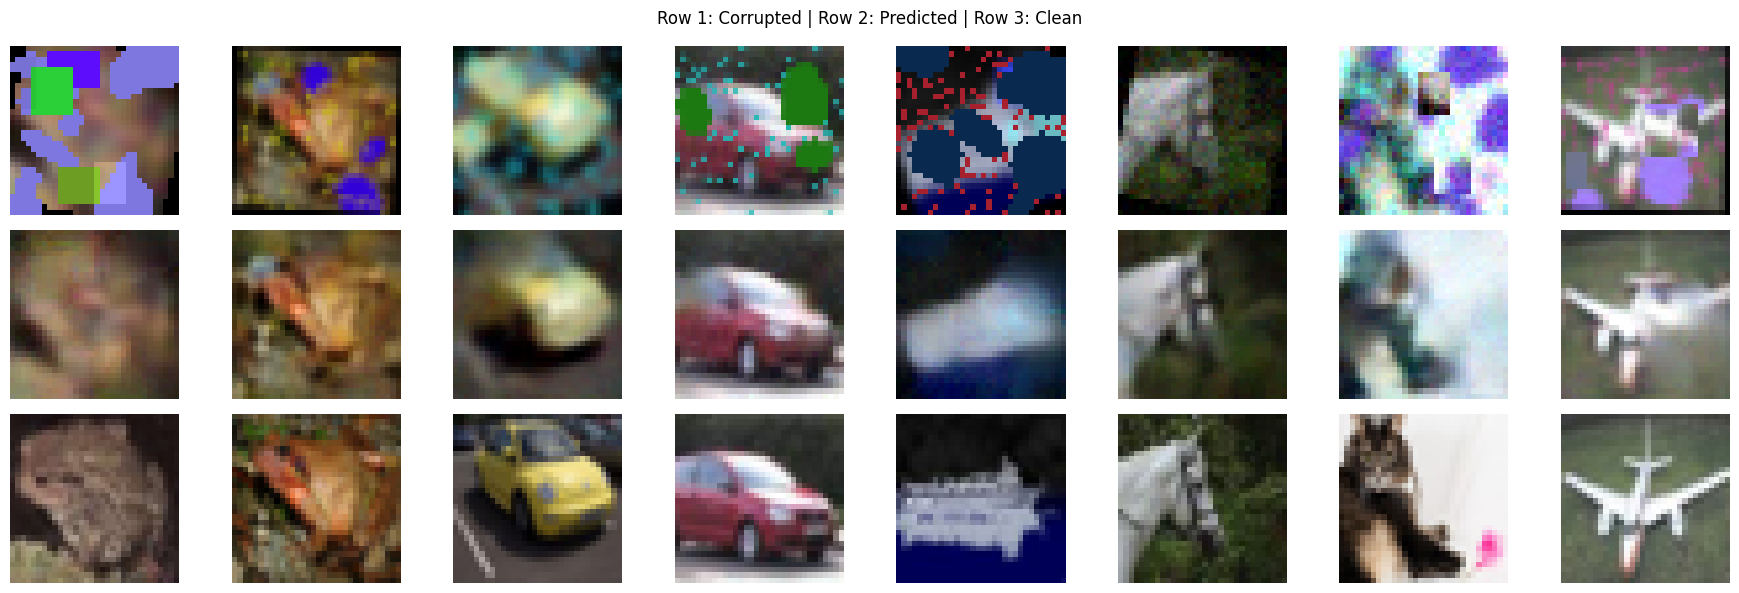

In [13]:
# Load best checkpoint
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

def to_uint8(tensor):
    """Convert normalised tensor [-1,1] (C,H,W) → uint8 numpy (H,W,C)."""
    arr = tensor.cpu().numpy().transpose(1, 2, 0)
    return ((arr + 1) * 127.5).clip(0, 255).astype(np.uint8)


# Grab a batch from validation
corrupt_batch, clean_batch = next(iter(val_dl))
with torch.no_grad():
    pred_batch = model(corrupt_batch.to(DEVICE)).cpu()

n_show = 8
fig, axes = plt.subplots(3, n_show, figsize=(18, 6))
fig.suptitle('Row 1: Corrupted | Row 2: Predicted | Row 3: Clean', fontsize=12)

for j in range(n_show):
    axes[0, j].imshow(to_uint8(corrupt_batch[j])); axes[0, j].axis('off')
    axes[1, j].imshow(to_uint8(pred_batch[j]));   axes[1, j].axis('off')
    axes[2, j].imshow(to_uint8(clean_batch[j]));   axes[2, j].axis('off')

plt.tight_layout()
plt.show()

In [14]:
# ── Per-image MSE comparison: corrupted vs model output ──
corrupt_mse_list  = []
restored_mse_list = []

model.eval()
with torch.no_grad():
    for corrupt, clean in tqdm(val_dl, desc='Computing val MSE'):
        pred = model(corrupt.to(DEVICE)).cpu()
        # Scale to 0-255
        c_255 = (corrupt + 1) * 127.5
        p_255 = (pred    + 1) * 127.5
        t_255 = (clean   + 1) * 127.5
        for i in range(corrupt.size(0)):
            corrupt_mse_list.append(F.mse_loss(c_255[i], t_255[i]).item())
            restored_mse_list.append(F.mse_loss(p_255[i], t_255[i]).item())

corrupt_mse  = np.mean(corrupt_mse_list)
restored_mse = np.mean(restored_mse_list)
improvement  = (corrupt_mse - restored_mse) / corrupt_mse * 100

print(f'Validation set ({len(val_files)} images):')
print(f'  Baseline MSE  (corrupted as-is): {corrupt_mse:.2f}')
print(f'  Model MSE     (our U-Net):        {restored_mse:.2f}')
print(f'  Improvement:                      {improvement:.1f}%')

Computing val MSE:   0%|          | 0/32 [00:00<?, ?it/s]

Validation set (4000 images):
  Baseline MSE  (corrupted as-is): 4822.19
  Model MSE     (our U-Net):        1142.79
  Improvement:                      76.3%


## 9. Test-Time Augmentation (TTA)

In [15]:
def tta_predict(model, corrupt_tensor):
    """
    Average predictions over original + horizontally flipped input.
    Returns tensor (B, C, H, W) in [-1, 1].
    """
    model.eval()
    with torch.no_grad():
        inp = corrupt_tensor.to(DEVICE)
        p1  = model(inp)
        p2  = torch.flip(model(torch.flip(inp, dims=[3])), dims=[3])  # flip & un-flip
    return ((p1 + p2) / 2).cpu()


# Quick TTA MSE check on a subset of validation
tta_mse_list = []
for corrupt, clean in tqdm(val_dl, desc='TTA validation'):
    pred  = tta_predict(model, corrupt)
    p_255 = (pred  + 1) * 127.5
    t_255 = (clean + 1) * 127.5
    for i in range(corrupt.size(0)):
        tta_mse_list.append(F.mse_loss(p_255[i], t_255[i]).item())

print(f'TTA val MSE: {np.mean(tta_mse_list):.2f} (vs {restored_mse:.2f} without TTA)')

TTA validation:   0%|          | 0/32 [00:00<?, ?it/s]

TTA val MSE: 1085.95 (vs 1142.79 without TTA)


## Submission CSV

In [16]:
sample_sub  = pd.read_csv(SAMPLE_SUB)
test_ids    = sample_sub['id'].tolist()
pixel_cols  = [f'pixel_{i}' for i in range(N_PIXELS)]

test_ds  = TestDataset(test_ids, TEST_COR)
test_dl  = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2)

model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

all_ids, all_pixels = [], []

with torch.no_grad():
    for img_ids, corrupt in tqdm(test_dl, desc='Generating submission'):
        pred = tta_predict(model, corrupt)   # (B, 3, 32, 32) in [-1,1]
        # Convert to 0-255 uint8
        pred_u8 = ((pred + 1) * 127.5).clamp(0, 255).byte()   # (B, C, H, W)
        # Reshape to (B, H, W, C) → flatten to (B, 3072)
        pred_u8 = pred_u8.permute(0, 2, 3, 1).reshape(pred_u8.size(0), -1).numpy()
        all_ids.extend(img_ids)
        all_pixels.append(pred_u8)

all_pixels = np.vstack(all_pixels)   # (12000, 3072)

sub_df = pd.DataFrame(all_pixels, columns=pixel_cols)
sub_df.insert(0, 'id', all_ids)

# Ensure correct row order (match sample submission)
sub_df = sub_df.set_index('id').loc[test_ids].reset_index()

sub_df.to_csv('submission.csv', index=False)
print(f'Saved submission.csv  →  {sub_df.shape[0]} rows × {sub_df.shape[1]} cols')
sub_df.head(2)

Generating submission:   0%|          | 0/47 [00:00<?, ?it/s]

Saved submission.csv  →  12000 rows × 3073 cols


,id,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4,pixel_5,pixel_6,pixel_7,pixel_8,...,pixel_3062,pixel_3063,pixel_3064,pixel_3065,pixel_3066,pixel_3067,pixel_3068,pixel_3069,pixel_3070,pixel_3071
0,test_00000,239,244,253,240,247,251,248,249,254,...,159,169,165,158,177,163,166,176,173,165
1,test_00001,128,182,241,125,181,245,124,180,248,...,58,104,86,61,102,88,61,94,82,57
